# 02 — Tokenisation and Transformer Inputs

This notebook investigates how DistilBERT converts raw English text into numerical inputs.

Goals:

* Understand WordPiece tokenisation.
* Learn special tokens.
* Understand token IDs.
* Understand attention masks.
* Prepare inputs for DistilBERT.


In [3]:
from transformers import AutoTokenizer

from news_sense.dataset import load_news_dataset
from news_sense.plotting import (
    set_plot_style,
    get_colour,
    get_palette
)
set_plot_style()

import pandas as pd
import matplotlib.pyplot as plt

## Load DistilBERT tokeniser

In [4]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

### Exploration into tokenisation 

In [5]:
sentence = "This sentence, with a subordinate clause, is for testing."
tokens = tokenizer.tokenize(sentence)

tokens

['this',
 'sentence',
 ',',
 'with',
 'a',
 'subordinate',
 'clause',
 ',',
 'is',
 'for',
 'testing',
 '.']

In [6]:
word = "supercalifragilisticexpialidocious"
print(word)
print(tokenizer.tokenize(word))
print()

supercalifragilisticexpialidocious
['super', '##cal', '##if', '##rag', '##ilis', '##tic', '##ex', '##pia', '##lid', '##oc', '##ious']



In [7]:
encoded = tokenizer(sentence)

encoded

{'input_ids': [101, 2023, 6251, 1010, 2007, 1037, 15144, 11075, 1010, 2003, 2005, 5604, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [8]:
tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

tokens

['[CLS]',
 'this',
 'sentence',
 ',',
 'with',
 'a',
 'subordinate',
 'clause',
 ',',
 'is',
 'for',
 'testing',
 '.',
 '[SEP]']

In [9]:
for token_id in encoded["input_ids"]:
    token = tokenizer.decode([token_id])
    print(token_id, "->", token)

101 -> [CLS]
2023 -> this
6251 -> sentence
1010 -> ,
2007 -> with
1037 -> a
15144 -> subordinate
11075 -> clause
1010 -> ,
2003 -> is
2005 -> for
5604 -> testing
1012 -> .
102 -> [SEP]


In [10]:
sentences = [
    "Wales won.",
    "Wales won the rugby match.",
    "Wales won the rugby match after extra time."
]

batch = tokenizer(
    sentences,
    padding=True
)

batch

{'input_ids': [[101, 3575, 2180, 1012, 102, 0, 0, 0, 0, 0, 0], [101, 3575, 2180, 1996, 4043, 2674, 1012, 102, 0, 0, 0], [101, 3575, 2180, 1996, 4043, 2674, 2044, 4469, 2051, 1012, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

In [11]:
for ids in batch["input_ids"]:
    print(tokenizer.convert_ids_to_tokens(ids))

['[CLS]', 'wales', 'won', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
['[CLS]', 'wales', 'won', 'the', 'rugby', 'match', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
['[CLS]', 'wales', 'won', 'the', 'rugby', 'match', 'after', 'extra', 'time', '.', '[SEP]']


In [12]:
batch["attention_mask"]

[[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
 [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]

the attention masks inform how much each token needs to be taken into account. so words should be looked at and padding should be ignored as it does not cary semantic info.

In [13]:
long_text = " ".join(["example"] * 600)

encoded = tokenizer(
    long_text,
    truncation=True,
    max_length=32
)

In [14]:
len(encoded["input_ids"])

32

## Tokenization of AG News dataset

In [15]:
dataset = load_news_dataset()

article = dataset["train"][0]["description"]

print(article)

Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


In [16]:
encoded = tokenizer(
    article,
    truncation=True,
    max_length=128
)

In [17]:
pd.DataFrame({
    "Token": tokenizer.convert_ids_to_tokens(encoded["input_ids"]),
    "ID": encoded["input_ids"],
    "Mask": encoded["attention_mask"]
}).head(25)

,Token,ID,Mask
0,[CLS],101,1
1,reuters,26665,1
2,-,1011,1
3,short,2460,1
4,-,1011,1
5,sellers,19041,1
6,",",1010,1
7,wall,2813,1
8,street,2395,1
9,',1005,1


In [18]:
token_lengths = []

for article in dataset["train"]["description"]:
    encoded = tokenizer(article)
    token_lengths.append(len(encoded["input_ids"]))

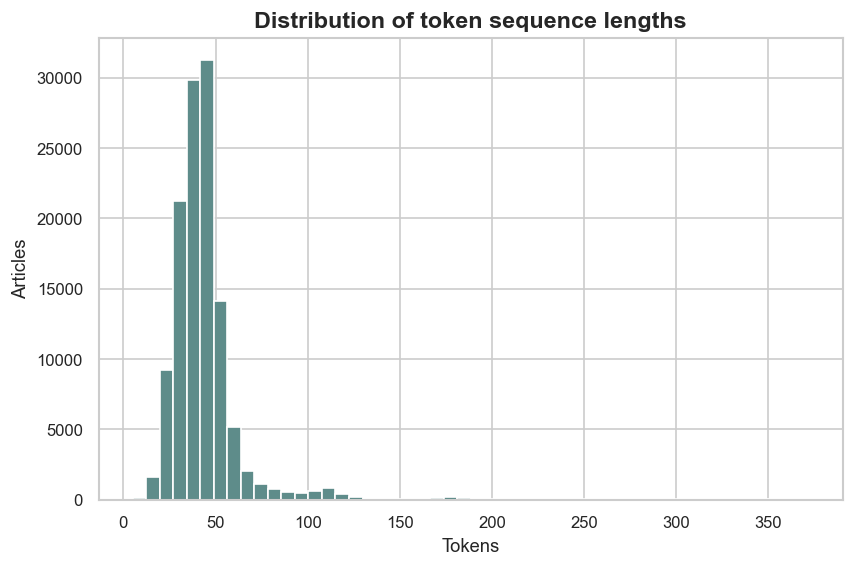

<Figure size 960x600 with 0 Axes>

In [19]:
plt.hist(token_lengths, bins=50, color = get_colour("secondary"))

plt.title("Distribution of token sequence lengths")
plt.xlabel("Tokens")
plt.ylabel("Articles")

plt.show()
plt.savefig("../figures/token_sequence_lengths.png", dpi=300)

## Key Takeaways

### WordPiece tokenisation

* Splits unknown words into known subwords.
* Allows a fixed vocabulary while representing millions of words.

### Special tokens

* `[CLS]` is the sentence representation used for classification.
* `[SEP]` marks sentence boundaries.
* `[PAD]` creates equal-length sequences.

### Attention masks

* `1` means "real token".
* `0` means "ignore this padding token".

### Padding and truncation

Transformers require fixed-size batches, so sequences are padded and optionally truncated to a maximum length.


## Exploring making a tokenizer

Now that I have seen how the tokenizer breaks down and encodes words into tokens, I want to explore building my own simple version to consolidate my understanding.

In [114]:
# build a small corpus to train on
corpus_size = 10000
corpus = dataset["train"].select(range(corpus_size))["description"]

im only using 5000 as the purpose of this exercise is to increase my understanding, rather than reproduce a tokenizer like BERT's vocabulary.

In [115]:
for i in range(3):
    print(f"Article {i}")
    print(corpus[i])
    print("-" * 60)

Article 0
Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
------------------------------------------------------------
Article 1
Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
------------------------------------------------------------
Article 2
Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
------------------------------------------------------------


### Training
First, the words need to be broken down into a list of characters, and an end-of-word symbol: "_".

In [116]:
def word_to_symbols(word):
    """
    Convert a word to a list of symbols and an end-of-word character.
    """
    return list(word) + ["_"]

In [117]:
word_to_symbols("hello")

['h', 'e', 'l', 'l', 'o', '_']

Apply this function to the corpus

In [118]:
import re #importing regex library to allow us to easily detect letters vs punctuation

words = []

for article in corpus:
    article = article.lower() # conver to lowercase

    article_words = re.findall(r"[a-z]+", article) # find all words in the article
    words.extend(article_words)

In [119]:
len(words)

324607

In [120]:
# build symbol sequences
symbol_sequences = [word_to_symbols(word) for word in words]

In [121]:
symbol_sequences[0]

['r', 'e', 'u', 't', 'e', 'r', 's', '_']

the next step, now that we have separated the words into characters, is to start building tokens by comparing how frequently groups of characters appear together.

In [122]:
from collections import Counter

def count_pairs(symbol_sequences):
    pair_counts = Counter() # Counter() is used here to

    for symbols in symbol_sequences:
        for i in range(len(symbols) - 1):
            pair = (symbols[i], symbols[i + 1])
            pair_counts[pair] += 1

    return pair_counts

In [123]:
pair_counts = count_pairs(symbol_sequences)

pair_counts.most_common(20)

[(('e', '_'), 48852),
 (('s', '_'), 48598),
 (('i', 'n'), 34297),
 (('t', 'h'), 31569),
 (('n', '_'), 31436),
 (('t', '_'), 30117),
 (('d', '_'), 29885),
 (('e', 'r'), 27221),
 (('h', 'e'), 26394),
 (('a', 'n'), 22564),
 (('o', 'n'), 21883),
 (('r', 'e'), 21753),
 (('y', '_'), 20029),
 (('r', '_'), 19066),
 (('t', 'e'), 18575),
 (('e', 's'), 17651),
 (('s', 't'), 16641),
 (('o', 'r'), 16543),
 (('e', 'd'), 16043),
 (('a', 't'), 15693)]

we then merge the most common pair into a new token

In [124]:
def merge_pair(symbol_sequences, pair_to_merge): 
    """
    function to merge all instances of the given pair when they appear together 
    in the symbol breakdown of the description, return the new symbol breakdowns 
    after merging
    """
    merged_sequences = [] # create a list to house the new symbol sequences after merging

    merged_token = "".join(pair_to_merge) # join the most common symbol pair into one token

    for symbols in symbol_sequences: # iterate through each symbol sequence in the list of symbol sequences
        new_symbols = [] # create a new list to house the new symbol sequence after merging

        i = 0 # start a counter to hold the index of the current symbol in the symbol sequence

        while i < len(symbols): # while the the index is still in the list
            if (
                i < len(symbols) - 1 # if not the last symbol
                and symbols[i] == pair_to_merge[0] # and if the 2 symbols in the pair are adjacent in this instance, 
                and symbols[i + 1] == pair_to_merge[1]
            ):
                new_symbols.append(merged_token) # merge the two symbols into one token and add it to the new symbol sequence
                i += 2  # skip the pair and look at the next symbol after the pair
            else:
                new_symbols.append(symbols[i]) # if the two symbols arent next to each other in this instance, add the current symbol to the new list on its own, and look at the next one
                i += 1

        merged_sequences.append(new_symbols) # add the new symbol sequence to the list of new symbol sequences

    return merged_sequences

In [125]:
best_pair = pair_counts.most_common(1)[0][0]

best_pair

('e', '_')

In [126]:
merged_sequences = merge_pair(symbol_sequences, best_pair)

In [127]:
print(symbol_sequences[1])
print(merged_sequences[0])

print(symbol_sequences[1])
print(merged_sequences[1])

['s', 'h', 'o', 'r', 't', '_']
['r', 'e', 'u', 't', 'e', 'r', 's', '_']
['s', 'h', 'o', 'r', 't', '_']
['s', 'h', 'o', 'r', 't', '_']


notice the 's', '_' has become 's_' in "reuters_", however in "short_", the 's' and the '_' are still separate symbols as they dont appear together, so the vocabulary is expanding. now we need to repeat this process to finish building up our token vocabulary.

In [128]:
import time

def train_bpe(symbol_sequences, num_merges=100):

    vocabulary = set([
        'a', 'b', 'c', 'd', 'e', 'f', 'g',
        'h', 'i', 'j', 'k', 'l', 'm', 'n', 
        'o', 'p', 'q', 'r', 's', 't', 'u', 
        'v', 'w', 'x', 'y', 'z', '_'
    ]) # use a set to avoid storing the same tokens multiple time, populate it initially with the alphabet and '_' end symbol and we will add the new tokens that we learn to this set as we go along

    merges = [] # store the merges that have been made, so we can use them later to encode new words

    current_sequences = symbol_sequences # start with the original breakdown of the words into characters

    start_time = time.time()
    for iteration in range(num_merges): # iterate throught the given number of merges

        pair_counts = count_pairs(current_sequences) # recalculate the most common pairs of symbols in the current vocabulary

        best_pair, frequency = pair_counts.most_common(1)[0] # take the single most common, this is the one we will merge on this iteration

        merges.append(best_pair) # add the pair to the list of merges

        vocabulary.add("".join(best_pair)) # merge the pair of symbols into one token and add it to the vocab

        current_sequences = merge_pair(current_sequences, best_pair) # create the new list by merging all adjacent instances of the pair

        if iteration % 10 == 0: # print a progress report after every 10 merges
            elapsed_time = time.time() - start_time
            print(f"Merge {iteration}: {best_pair} ({frequency}) - Elapsed Time: {elapsed_time:.2f} seconds")
            start_time = time.time()

    return current_sequences, vocabulary, merges

In [129]:
trained_sequences, vocabulary, merges = train_bpe(
    symbol_sequences,
    num_merges=corpus_size//20
)

Merge 0: ('e', '_') (48852) - Elapsed Time: 7.71 seconds
Merge 10: ('a', 'n') (16698) - Elapsed Time: 44.17 seconds
Merge 20: ('o', 'n_') (11137) - Elapsed Time: 16.53 seconds
Merge 30: ('i', 't') (8653) - Elapsed Time: 18.95 seconds
Merge 40: ('al', '_') (5761) - Elapsed Time: 16.70 seconds
Merge 50: ('or', '_') (4857) - Elapsed Time: 17.33 seconds
Merge 60: ('i', 's_') (4125) - Elapsed Time: 15.43 seconds
Merge 70: ('u', 's') (3268) - Elapsed Time: 26.13 seconds
Merge 80: ('i', 't_') (2631) - Elapsed Time: 23.82 seconds
Merge 90: ('s', 'a') (2356) - Elapsed Time: 21.64 seconds
Merge 100: ('a', 'p') (2118) - Elapsed Time: 14.41 seconds
Merge 110: ('ig', 'h') (1915) - Elapsed Time: 12.47 seconds
Merge 120: ('h', 'a') (1793) - Elapsed Time: 12.18 seconds
Merge 130: ('o', 'w') (1644) - Elapsed Time: 19.15 seconds
Merge 140: ('e', 't_') (1573) - Elapsed Time: 20.84 seconds
Merge 150: ('m', 'on') (1441) - Elapsed Time: 13.13 seconds
Merge 160: ('i', 'st') (1358) - Elapsed Time: 12.10 secon

In [130]:
sorted(list(vocabulary))[:100]

['_',
 'a',
 'a_',
 'ab',
 'able_',
 'about_',
 'ac',
 'ace_',
 'ack',
 'ack_',
 'ad',
 'ad_',
 'ade_',
 'af',
 'after_',
 'ag',
 'again',
 'against_',
 'age_',
 'ail',
 'ain',
 'ain_',
 'air',
 'aj',
 'ak',
 'al',
 'al_',
 'all',
 'all_',
 'ally_',
 'als_',
 'am',
 'am_',
 'amer',
 'americ',
 'amp',
 'an',
 'an_',
 'anc',
 'ance_',
 'and',
 'and_',
 'ang',
 'ann',
 'ans_',
 'ant',
 'ant_',
 'any_',
 'ap',
 'ap_',
 'aq',
 'ar',
 'ar_',
 'ard_',
 'are',
 'are_',
 'arg',
 'ary_',
 'as',
 'as_',
 'ase_',
 'ash',
 'ass',
 'ast',
 'ast_',
 'at',
 'at_',
 'ate_',
 'ated_',
 'ates_',
 'ath',
 'athens_',
 'ating_',
 'ation_',
 'ations_',
 'att',
 'au',
 'av',
 'aw',
 'ay',
 'ay_',
 'ays_',
 'b',
 'b_',
 'ban',
 'bas',
 'be',
 'be_',
 'bec',
 'been_',
 'bl',
 'bo',
 'br',
 'bu',
 'bus',
 'but_',
 'by_',
 'c',
 'car',
 'ce_']

### Encoding
now that we have built the tokens up a bit, we can start using them to encode our words using a greedy algorithm to work left to right along the word, finding the largest possible tokens at each stop.

In [150]:
vocab = sorted(vocabulary, key=len, reverse=True) # sort the vocabulary by length, longest first, so that we can match the longest tokens first when encoding new words

def encode_word(word, vocabulary): # function to encode a new word using the trained vocabulary, by matching the longest tokens first

    # need to check that words end in '_' character
    if word[-1] != '_':
        word += '_' # add the end of word character if it is not already there

    symbols = word.lower() # convert the word to lowercase

    tokens = [] # empty list to hold the tokens that we will find in the word

    i = 0 # counter to hold the index of the symbol with which our current token with start

    while i < len(symbols): # ensure the starting symbol index is within the word

        match = None # initialise a match placeholder

        for token in vocabulary: # iterate through the available tokens
            if symbols.startswith(token, i): # check that the current token matches the symbols starting at the current index
                match = token # if a token matches the symbols, store it in the match placeholder
                break # the tokens are ordered largest to smallest, so we know the first match is the largest so can stop searching

        if match is None: # if we dont find a matching token
            tokens.append(symbols[i]) # add the current symbol to the list of tokens, as we have no larger token to match it with
            i += 1 # look at the next symbol in the word
        else:
            tokens.append(match) # add the matching token to the list of tokens
            i += len(match) # skip the rest of the token and look at the next symbol in the word that wasnt in the token.

    return tokens # return the list of tokens that make up the word

In [ ]:
test_words = [
    "unbelievable",
    "preprocessing",
    "transformers",
    "placement",
    "bioinformatics",
    "original",
    "compensation",
    "candidate",
    "responsible",
    "material"
]

for word in test_words:
    print(word)
    print(encode_word(word, vocab))
    print()

unbelievable
['un', 'be', 'li', 'ev', 'able_']

preprocessing
['pre', 'pro', 'c', 'ess', 'ing_']

transformers
['tr', 'an', 's', 'form', 'ers_']

placement
['pl', 'ac', 'em', 'ent_']

bioinformatics
['b', 'i', 'o', 'in', 'form', 'at', 'ics_']



In [152]:
token_lengths = [len(token) for token in vocabulary]

pd.Series(token_lengths).describe()

count    527.000000
mean       3.356736
std        1.534727
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       11.000000
dtype: float64

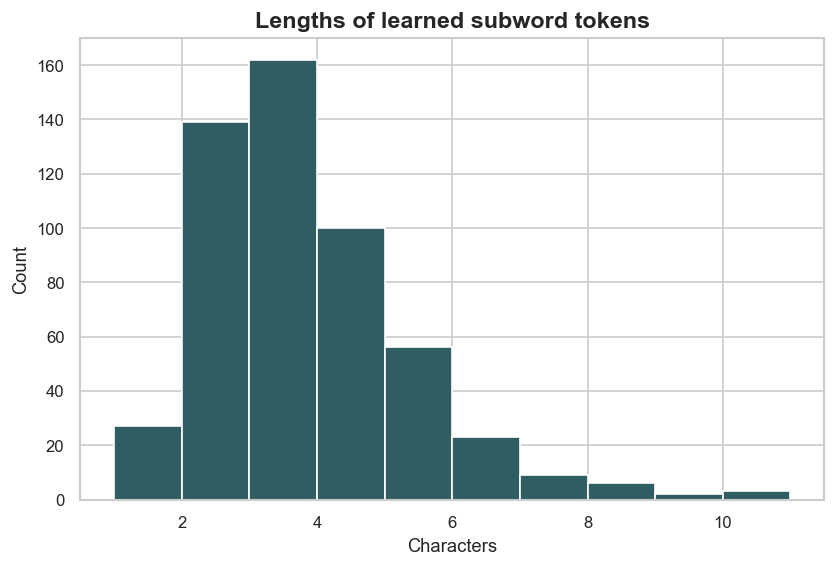

In [153]:
plt.hist(token_lengths, bins=10, color=get_colour("primary"))

plt.title("Lengths of learned subword tokens")
plt.xlabel("Characters")
plt.ylabel("Count")

plt.show()

In [135]:
sorted(vocabulary, key=len, reverse=True)[:20]

['government_',
 'wednesday_',
 'yesterday_',
 'national_',
 'thursday_',
 'company_',
 'against_',
 'olympic_',
 'reuters_',
 'tuesday_',
 'million_',
 'monday_',
 'prices_',
 'friday_',
 'ations_',
 'athens_',
 'second_',
 'united_',
 'sunday_',
 'illion_']

now lets assign each token a unique id to be used for look up

In [136]:
token_to_id = {token: idx for idx, token in enumerate(sorted(vocabulary))}
id_to_token = {idx: token for token, idx in token_to_id.items()}

In [137]:
id_to_token[26]

'al_'

In [154]:
token_to_id['able_']

4

In [156]:
test_words = pd.DataFrame({
    "word": [
        "unbelievable",
        "preprocessing",
        "transformers",
        "placement",
        "bioinformatics",
        "original",
        "compensation",
        "candidate",
        "responsible",
        "material"
    ]
})

test_words["tokens"] = test_words["word"].apply(lambda x: encode_word(x, vocab))
test_words["ids"] = test_words["tokens"].apply(lambda x: [token_to_id[token] for token in x])

test_words

,word,tokens,ids
0,unbelievable,"[un, be, li, ev, able_]","[480, 86, 287, 169, 4]"
1,preprocessing,"[pre, pro, c, ess, ing_]","[385, 389, 97, 162, 242]"
2,transformers,"[tr, an, s, form, ers_]","[466, 36, 412, 181, 158]"
3,placement,"[pl, ac, em, ent_]","[378, 6, 144, 153]"
4,bioinformatics,"[b, i, o, in, form, at, ics_]","[82, 209, 325, 236, 181, 65, 221]"
5,original,"[or, ig, in, al_]","[348, 225, 236, 26]"
6,compensation,"[comp, en, sat, ion_]","[108, 146, 417, 249]"
7,candidate,"[c, and, id, ate_]","[97, 40, 222, 67]"
8,responsible,"[res, po, n, s, ib, le_]","[406, 380, 313, 412, 214, 285]"
9,material,"[m, at, er, ial_]","[295, 65, 155, 212]"
